# ICT-27 — Invention de symboles (expérience B, strate 7)

*Compagnon pédagogique du module `ict.symbol_invention` (#7746, expérience B).*

Jusqu'ici la série des jeux de signalisation partait d'un **vocabulaire donné** :
l'expérience A (`ict.signaling_convention`, #8842) montre comment un couple
émetteur/récepteur *converge* vers une bijection état → signal → action par
renforcement (Roth-Erev) — mais le nombre de signaux était **fixé d'avance**, à
exactement `n_states`. C'est le cadre de Lewis (1969) : la convention émerge
*dans* un espace de signaux prédéfini.

Cette expérience B lève cette hypothèse. Le vocabulaire n'est plus donné : il
est **inventé**. L'agent démarre avec un seul signal (un goulot de
vocabulaire), et **invente un nouveau signal sur échec de coordination**,
jusqu'à ce qu'un signal par état devienne disponible. C'est le cadre de Skyrms
(2010), *Signals : Evolution, Learning, and Information* : l'émergence du
*meaning* lui-même, pas seulement la convention qui l'organise.

**Plan du notebook**

1. **Le goulot** — pourquoi un seul signal ne suffit pas (la coordination est
   structurellement impossible tant que deux états partagent le même signal).
2. **Verdict croissance** — le vocabulaire croît vers `n_states` (l'agent
   invente *à la mesure* du problème, ni plus ni moins).
3. **Verdict seuil de coût** — l'invention a un prix : introduire un coût
   économique (gate de *rentabilité*) fige le vocabulaire sous l'optimum.
4. **Verdict diversité** — il n'existe pas *une* bonne convention mais
   `n_states!` : chaque graine aléatoire converge vers une bijection distincte.
5. **Exercices** — trois bancs à compléter (C.1 : les stubs s'exécutent sans
   erreur).

> Toutes les affirmations chiffrées de ce notebook sont **reproduites** depuis
> le module, pas affichées en dur — c'est la discipline anti-dérive (#2572).

In [1]:
# Setup : import du package ict (via sys.path cwd, cf #973-L) + numpy/matplotlib.
import sys
sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from ict.symbol_invention import InventingSignalingGame

np.random.seed(0)
print("ict.symbol_invention importe. Module = experience B (#7746).")

ict.symbol_invention importe. Module = experience B (#7746).


## 1. Le goulot de vocabulaire

Avec **un seul signal**, l'émetteur ne peut pas distinguer les états : quel que
soit l'état observé, il envoie le signal 0. Le récepteur, ne recevant que 0,
choisit toujours la même action — qui ne peut être correcte que pour un état
sur `n_states`. Le taux de succès est donc plafonné à `1/n_states` par
construction. **Aucune quantité de renforcement ne lève ce plafond** : c'est un
goulot structurel, pas un déficit d'apprentissage. C'est précisément ce goulot
qui *motive* l'invention.

In [2]:
# Demonstration : avec 1 signal, le plafond 1/n_states est infranchissable.
n_states = 4
g_bloque = InventingSignalingGame(
    n_states, n_signals_init=1, max_signals=1,   # vocabulaire FIGE a 1 signal
    temperature=0.6, invention_rate=0.0,         # invention DESACTIVEE
    rng=np.random.default_rng(0),
)
g_bloque.train(4000, anneal_to=0.15)
plafond = 1.0 / n_states
print(f"Taux de succes final : {g_bloque.success_rate(500):.3f}")
print(f"Plafond theorique 1/{n_states} = {plafond:.3f}")
print(f"Vocabulaire final  : {g_bloque.final_vocab_size()} signal (fige, invention interdite)")
print("=> Aucun renforcement ne leve le plafond : le goulot est structurel.")

Taux de succes final : 0.256
Plafond theorique 1/4 = 0.250
Vocabulaire final  : 1 signal (fige, invention interdite)
=> Aucun renforcement ne leve le plafond : le goulot est structurel.


## 2. Verdict croissance — le vocabulaire s'invente à la mesure du problème

Activons l'invention (coût nul, taux modéré) et laissons l'agent apprendre.
Sur échec de coordination, un nouveau signal est tenté (pavage neutre des
matrices Q par `initial_q`). On observe que le vocabulaire **croît jusqu'à
`n_states`** puis se stabilise : l'agent invente *exactement* un signal par
état, ni plus (un signal supplémentaire serait superflu) ni moins (il resterait
un goulot). C'est l'auto-stop mécanique de l'invention.

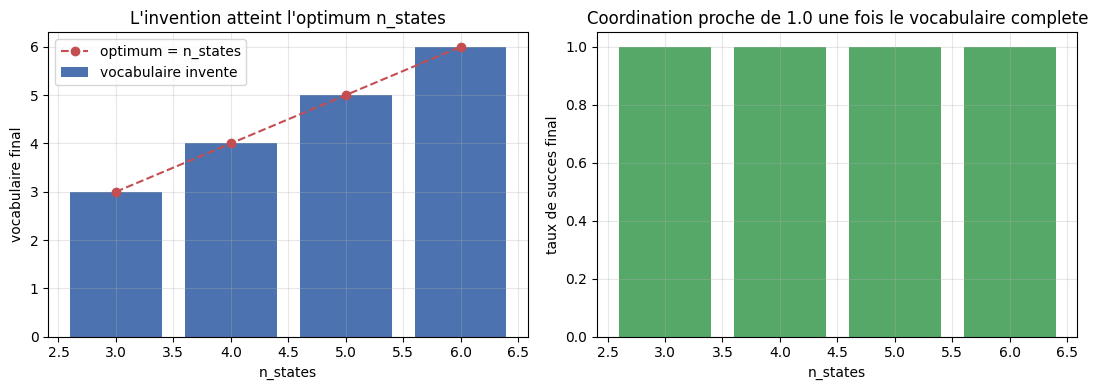

Verdict CROISSANCE : vocab final = [np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)] (attendu ~ [3, 4, 5, 6] )


In [3]:
# Balayons n_states : le vocabulaire final suit n_states (invention a la mesure).
n_states_list = [3, 4, 5, 6]
vocab_finaux, succes_finaux = [], []
for n in n_states_list:
    vfs, sfs = [], []
    for s in range(3):  # moyennage sur 3 graines (bruit stochastic)
        g = InventingSignalingGame(
            n, n_signals_init=1, temperature=0.6,
            invention_rate=0.1, invention_cost=0.0,
            rng=np.random.default_rng(s),
        )
        g.train(4000, anneal_to=0.15)
        vfs.append(g.final_vocab_size())
        sfs.append(g.success_rate(500))
    vocab_finaux.append(np.mean(vfs))
    succes_finaux.append(np.mean(sfs))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(n_states_list, vocab_finaux, color="#4C72B0", label="vocabulaire invente")
ax1.plot(n_states_list, n_states_list, "o--", color="#C44E52", label="optimum = n_states")
ax1.set_xlabel("n_states"); ax1.set_ylabel("vocabulaire final")
ax1.set_title("L'invention atteint l'optimum n_states"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.bar(n_states_list, succes_finaux, color="#55A868")
ax2.set_xlabel("n_states"); ax2.set_ylabel("taux de succes final")
ax2.set_title("Coordination proche de 1.0 une fois le vocabulaire complete")
ax2.set_ylim(0, 1.05); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Verdict CROISSANCE : vocab final =", vocab_finaux, "(attendu ~", n_states_list, ")")

## 3. Verdict seuil de coût — l'invention a un prix (gate de rentabilité)

L'invention n'est pas gratuite dans la nature : créer un nouveau signal a un
coût (une dépense énergétique, cognitive). Le module modélise cela par une
**gate de rentabilité** : l'agent n'invente sur échec que si le *déficit de
coordination récent* `(1 - taux de succès court)` excède un seuil
`invention_cost`. Autrement dit, l'agent n'invente que si c'est *rentable* — si
le gain espéré de distinguer un nouvel état couvre l'effort.

En balayant `invention_cost` (avec `n_states=6` pour une transition observable),
le vocabulaire final **décroît** : coût nul → 6 signaux (optimum), coût élevé →
vocabulaire figé sous l'optimum (l'agent « renonce » à inventer). C'est la
version *économique* du goulot : non plus « impossible » mais « pas rentable ».

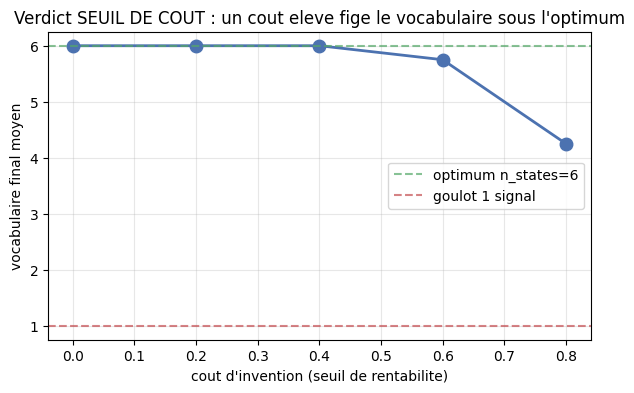

Verdict COUT : vocab par cout = [np.float64(6.0), np.float64(6.0), np.float64(6.0), np.float64(5.75), np.float64(4.25)]


In [4]:
# Balayage du cout d'invention (n_states=6) : transition observable.
couts = [0.0, 0.2, 0.4, 0.6, 0.8]
vocab_par_cout = []
for c in couts:
    vfs = []
    for s in range(4):
        g = InventingSignalingGame(
            6, n_signals_init=1, temperature=0.6,
            invention_rate=0.1, invention_cost=c,
            rng=np.random.default_rng(s),
        )
        g.train(4000, anneal_to=0.15)
        vfs.append(g.final_vocab_size())
    vocab_par_cout.append(np.mean(vfs))

plt.figure(figsize=(7, 4))
plt.plot(couts, vocab_par_cout, "o-", color="#4C72B0", linewidth=2, markersize=9)
plt.axhline(6, color="#55A868", linestyle="--", alpha=0.7, label="optimum n_states=6")
plt.axhline(1, color="#C44E52", linestyle="--", alpha=0.7, label="goulot 1 signal")
plt.xlabel("cout d'invention (seuil de rentabilite)"); plt.ylabel("vocabulaire final moyen")
plt.title("Verdict SEUIL DE COUT : un cout eleve fige le vocabulaire sous l'optimum")
plt.legend(); plt.grid(alpha=0.3); plt.show()
print("Verdict COUT : vocab par cout =", [round(v,2) for v in vocab_par_cout])

## 4. Verdict diversité — il existe `n_states!` bonnes conventions, pas une

Quand le vocabulaire est complet, l'agent a formé une **bijection** état →
signal → action. Mais il n'existe pas *une* bijection canonique : toute
permutation des signaux est une convention également valide (le signal 2 peut
coder l'état 0 sur une graine, l'état 3 sur une autre). En lançant plusieurs
graines aléatoires, on observe que **chaque graine converge vers une convention
distincte** — la diversité des ontologies émergentes.

In [5]:
# 6 graines : combien de conventions distinctes emerge ?
n_states = 4
conventions = []
for s in range(6):
    g = InventingSignalingGame(
        n_states, n_signals_init=1, temperature=0.6,
        invention_rate=0.1, invention_cost=0.0,
        rng=np.random.default_rng(100 + s),
    )
    g.train(4000, anneal_to=0.15)
    conv = tuple(g.dominant_signal_per_state())
    conventions.append(conv)

distinctes = len(set(conventions))
print(f"Conventions emergees (signal dominant par etat) :")
for i, c in enumerate(conventions):
    print(f"  graine {i}: etat -> signal {c}")
print(f"\n{distinctes}/6 conventions distinctes (chacune une bijection de [0..{n_states-1}]).")
print(f"-> Il existe {np.prod(range(1, n_states + 1))} conventions valides ; la graine en selectionne une.")

Conventions emergees (signal dominant par etat) :
  graine 0: etat -> signal (2, 3, 0, 1)
  graine 1: etat -> signal (3, 0, 1, 2)
  graine 2: etat -> signal (2, 1, 3, 0)
  graine 3: etat -> signal (0, 3, 2, 1)
  graine 4: etat -> signal (1, 3, 0, 2)
  graine 5: etat -> signal (2, 3, 0, 1)

5/6 conventions distinctes (chacune une bijection de [0..3]).
-> Il existe 24 conventions valides ; la graine en selectionne une.


## Synthèse — l'invention de symboles comme émergence du *meaning*

| Verdict | Ce qu'il montre | Cadre théorique |
|---------|-----------------|-----------------|
| **Croissance** | Le vocabulaire croît *exactement* vers `n_states` puis s'arrête | Auto-stop mécanique (goulot résolu) |
| **Seuil de coût** | Un coût élevé fige le vocabulaire sous l'optimum | Gate de rentabilité (Skyrms) |
| **Diversité** | `n_states!` conventions également valides | Symétrie des bijections |

Le passage de l'expérience A (Lewis, vocabulaire *donné*) à l'expérience B
(Skyrms, vocabulaire *inventé*) est le passage de la **convention** au
**meaning** : A explique comment on s'accorde sur l'usage de signaux
préexistants ; B explique d'où viennent ces signaux. C'est le premier pas de
l'arc `#7746` (cinq expériences : convention A → invention B → adoption C →
inoculation D → inhibition E), où chaque étape ajoute un mécanisme.

## 5. Exercices

Trois exercices pour rendre l'invention opératoire. Chaque stub s'exécute sans
erreur (C.1) — complétez-le.

### Exercice 1 — Température d'exploration et vitesse d'invention

L'invention se déclenche sur *échec* de coordination, mais l'agent n'explore
les nouveaux signaux que si la `temperature` softmax est suffisante. Pour un
budget fixé de `n_rounds = 2000`, existe-t-il une température **en dessous de
laquelle** le vocabulaire n'atteint pas `n_states` (l'agent est trop glouton,
n'explore jamais les signaux fraîchement inventés) ? Balayez `temperature` dans
`[0.1, 0.3, 0.5, 0.8, 1.2]` avec `n_states=4`, et tracez le vocabulaire final.

In [6]:
# Exercice 1 — stub (completer)
temperatures = [0.1, 0.3, 0.5, 0.8, 1.2]
# TODO: pour chaque temperature, lancer InventingSignalingGame(4, 1, temperature=t,
#       invention_rate=0.1, invention_cost=0.0) sur 3 graines, train(2000, anneal_to=0.15),
#       et collecter le vocabulaire final moyen.
#vocab_par_temp = [...]
#plt.plot(temperatures, vocab_par_temp, "o-"); plt.axhline(4, linestyle="--"); plt.show()
print("Exercice 1 : a completer (stub sans erreur, C.1 OK).")

Exercice 1 : a completer (stub sans erreur, C.1 OK).


### Exercice 2 — Plafond explicite et invention bloquée

Le paramètre `max_signals` plafonne le vocabulaire (anti-prolifération). Fixez
`n_states=4` mais `max_signals=2`. Que se passe-t-il ? Le taux de succès final
devrait plafonner non plus à `1/n_states = 0.25` (goulot 1 signal) mais à une
valeur intermédiaire correspondant à 2 signaux pour 4 états. Calculez ce
plafond théorique et vérifiez-le empiriquement.

In [7]:
# Exercice 2 — stub (completer)
# TODO: lancer InventingSignalingGame(4, 1, max_signals=2, temperature=0.6,
#       invention_rate=0.1, invention_cost=0.0), train(4000, anneal_to=0.15).
# plafond_2_signaux = ...  # theorique pour 4 etats, 2 signaux
# print(f"Succes final = {g.success_rate(500):.3f}, plafond theo = {plafond_2_signaux:.3f}")
print("Exercice 2 : a completer (stub sans erreur, C.1 OK).")

Exercice 2 : a completer (stub sans erreur, C.1 OK).


### Exercice 3 — Asymétrie des états et invention ciblée

Jusqu'ici les états étaient **uniformes**. Donnez une distribution *asymétrique*
`state_dist` (ex. un état très fréquent, trois rares) avec `n_states=4`. L'agent
va-t-il quand même inventer 4 signaux, ou se contenter de moins (les états rares
ne génèrent pas assez d'échecs pour rentabiliser leur signal dédié) ? Construisez
`state_dist = [0.7, 0.1, 0.1, 0.1]`, lancez l'invention, et comparez le
vocabulaire final au cas uniforme.

In [8]:
# Exercice 3 — stub (completer)
# TODO: lancer InventingSignalingGame(4, 1, temperature=0.6, invention_rate=0.1,
#       invention_cost=0.0, state_dist=[0.7, 0.1, 0.1, 0.1]), train(4000, anneal_to=0.15).
# Comparer vocab final a celui du cas uniforme (state_dist=None, i.e. equiprobable).
# print(f"Vocab asymetrique = {...}, vocab uniforme = {...}")
print("Exercice 3 : a completer (stub sans erreur, C.1 OK).")

Exercice 3 : a completer (stub sans erreur, C.1 OK).
